# Data Augmentation

In [666]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

df_qs = pd.ExcelFile("University Ranking by Major 2025.xlsx")
df_fl = pd.read_pickle('ML_Trat.pkl')

## Extrapolar valores scores para las universidades 101-500

In [667]:
sheets = df_qs.sheet_names
sheets.pop(0)

dfs = []

gradiente = 0.0008 # +0.001 -> ultimos valores score mas bajos / -0.001 -> ultimos valores score mas altos

for sheet in sheets:
    dfR = pd.read_excel('University Ranking by Major 2025.xlsx', sheet_name=sheet, header=10)
    dfR = dfR[["Institution", "Country / Territory","Score"]].copy()
    last_valid = dfR["Score"].last_valid_index()
    final_score = dfR.loc[last_valid, "Score"]
    for i in range(last_valid + 1, len(dfR)):
        dfR.at[i, "Score"] = final_score * np.exp(-gradiente * (i - last_valid))
    dfR["Major"] = sheet
    dfs.append(dfR)


df_qs = pd.concat(dfs, ignore_index=True)
df_qs["Score"] = df_qs["Score"].round(1)
df_qs["Institution"] = df_qs["Institution"].str.upper()
df_qs["Country / Territory"] = df_qs["Country / Territory"].str.upper()
df_qs.loc[df_qs['Country / Territory'] == 'UNITED STATES OF AMERICA', 'Country / Territory'] = 'UNITED STATES'
df_qs.loc[df_qs['Country / Territory'] == 'CHINA (MAINLAND)', 'Country / Territory'] = 'CHINA'
df_qs.loc[df_qs['Country / Territory'] == 'VENEZUELA (BOLIVARIAN REPUBLIC OF)', 'Country / Territory'] = 'VENEZUELA'
df_qs.loc[df_qs['Country / Territory'] == 'IRAN (ISLAMIC REPUBLIC OF)', 'Country / Territory'] = 'IRAN'

In [670]:
df_qs.tail(50)

,Institution,Country / Territory,Score,Major
21042,UNIVERSITAT DE BARCELONA,SPAIN,69.6,Statistics
21043,UNIVERSITÄT HAMBURG,GERMANY,69.6,Statistics
21044,UNIVERSITÉ LAVAL,CANADA,69.5,Statistics
21045,UNIVERSITI SAINS MALAYSIA (USM),MALAYSIA,69.4,Statistics
21046,UNIVERSITY AT BUFFALO SUNY,UNITED STATES,69.4,Statistics
21047,UNIVERSITY COLLEGE DUBLIN,IRELAND,69.3,Statistics
21048,UNIVERSITY OF CALGARY,CANADA,69.3,Statistics
21049,"UNIVERSITY OF CALIFORNIA, SANTA BARBARA (UCSB)",UNITED STATES,69.2,Statistics
21050,UNIVERSITY OF DELHI,INDIA,69.2,Statistics
21051,UNIVERSITY OF GLASGOW,UNITED KINGDOM,69.1,Statistics


In [672]:
df_qs["Major"].unique()

array(['Arts & Humanities', 'Archaeology', 'Architecture', 'Art & Design',
       'Classics', 'English Language', 'History$', 'History of Art',
       'Linguistics', 'Modern Languages', 'Music', 'Performing Arts',
       'Philosophy', 'Theology', 'Engineering & Technology',
       'Computer Science', 'Data Science', 'Engineering - Chemical',
       'Engineering - Civil', 'Engineering - Electrical',
       'Engineering - Mechanical', 'Engineering - Mineral',
       'Petroleum Engineering', 'Life Sciences & Medicine', 'Agriculture',
       'Anatomy', 'Biological', 'Dentistry', 'Medicine', 'Nursing',
       'Pharmacy', 'Psychology', 'Veterinary Science', 'Natural Sciences',
       'Chemistry', 'Earth & Marine Sciences', 'Environmental Sciences',
       'Geography', 'Geology', 'Geophysics', 'Mathematics',
       'Materials Science', 'Physics', 'Social Sciences & Management',
       'Accounting', 'Anthropology', 'Business', 'Communication',
       'Development Studies', 'Economics & Econome

## Mapear Carreras

In [673]:
categories = [
    'Arts & Humanities', 'Archaeology', 'Architecture', 'Art & Design', 'Classics',
    'English Language', 'History$', 'History of Art', 'Linguistics', 'Modern Languages',
    'Music', 'Performing Arts', 'Philosophy', 'Theology', 'Engineering & Technology',
    'Computer Science', 'Data Science', 'Engineering - Chemical', 'Engineering - Civil',
    'Engineering - Electrical', 'Engineering - Mechanical', 'Engineering - Mineral',
    'Petroleum Engineering', 'Life Sciences & Medicine', 'Agriculture', 'Anatomy',
    'Biological', 'Dentistry', 'Medicine', 'Nursing', 'Pharmacy', 'Psychology',
    'Veterinary Science', 'Natural Sciences', 'Chemistry', 'Earth & Marine Sciences',
    'Environmental Sciences', 'Geography', 'Geology', 'Geophysics', 'Mathematics',
    'Materials Science', 'Physics', 'Social Sciences & Management', 'Accounting',
    'Anthropology', 'Business', 'Communication', 'Development Studies', 'Economics & Econometrics',
    'Education', 'Hospitality', 'Law', 'Library', 'Marketing', 'Politics',
    'Social Policy', 'Sociology', 'Sports-related Subjects', 'Statistics'
]

keywords_map = {
    'Computer Science': ['computer', 'artificial intell', 'ai'],
    'Engineering - Mechanical': ['mechanical engineering', 'automotive', 'aerospace', 'aeronautics', 'astronautics'],
    'Engineering - Electrical': ['electrical', 'electronic', 'mechatronics', 'robotics'],
    'Engineering - Chemical': ['chemical'],
    'Data Science': ['data science', 'analytics', 'ds', 'datos'],
    'Business': ['business', 'management', 'ade', 'marketing', 'finance', 'accounting', 'wbb', 'bba', 'empresa', 'iap', 'international foundation program'],
    'Economics & Econometrics': ['economics', 'econometrics', 'economia'],
    'Psychology': ['psychology', 'neuroscience', 'cognitive'],
    'Biological': ['biology', 'biological', 'biomedical', 'genetic', 'biotechnology', 'physiology'],
    'Medicine': ['medicine', 'medical'],
    'Law': ['law', 'legal', 'derecho'],
    'Architecture': ['architecture', 'architectural'],
    'Music': ['music', 'guitar'],
    'Performing Arts': ['acting', 'drama', 'film', 'screenwriting', 'screen'],
    'Mathematics': ['mathematics', 'math', 'algebra'],
    'Physics': ['physics', 'astronomy'],
    'Chemistry': ['chemistry', 'biochemistry'],
    'Sports-related Subjects': ['sports science', 'exercise', 'sport'],
    'Veterinary Science': ['veterinary', 'equine'],
    'Politics': ['politics', 'international relations', 'law', 'relaciones intern'],
    'Arts & Humanities': ['liberal arts', 'arts & sciences', 'bachelor of arts', 'creative writing'],
    'Natural Sciences': ['maastricht science program', 'bachelor or science', 'sciences'],
    'Life Sciences & Medicine': ['life science'],
    'Social Sciences & Management': ['social science'],
    'Engineering & Technology': ['engineering', 'technology', 'engineering technology'],
    'Engineering - Civil': ['civil engineering'],
    'Engineering - Mineral': ['mineral engineering'],
    'Petroleum Engineering': ['petroleum engineering'],
    'Environmental Sciences': ['environmental science'],
    'Geophysics': ['geophysics'],
    'Geology': ['geology'],
    'Geography': ['geography'],
    'Materials Science': ['materials science'],
    'Earth & Marine Sciences': ['earth & marine sciences'],
    'Statistics': ['statistics', 'statistical science'],
    'History of Art': ['history of art'],
    'History$': ['history', 'classical studies'],
    'Philosophy': ['philosophy'],
    'Theology': ['theology'],
    'Linguistics': ['linguistics'],
    'Modern Languages': ['modern languages'],
    'English Language': ['english language'],
    'Classics': ['classics'],
    'Art & Design': ['art & design', 'diseño de producto'],
    'Archaeology': ['archaeology'],
    'Agriculture': ['agriculture', 'agricultural'],
    'Nursing': ['nursing', 'nursing science'],
    'Social Policy': ['social policy', 'social work', 'refugees', 'migration', 'public health', 'health services administration'],
    'Sociology': ['sociology', 'social sciences', 'criminology'],
    'Dentistry': ['dentistry', 'oral', 'dental'],
}

### Checking de mapeo carreras

In [675]:
# Diccionario para agrupar
grouped = {cat: [] for cat in categories}

# Asignación
for career in df_fl["degree"].unique():
    career_lower = career.lower()
    matched = False
    for category, keywords in keywords_map.items():
        if any(keyword in career_lower for keyword in keywords):
            grouped[category].append(career)
            matched = True
            break
    if not matched:
        grouped.setdefault('Uncategorized', []).append(career)

# Mostrar resultados
for cat, items in grouped.items():
    if items:
        print(f"\n{cat} ({len(items)}):")
        for item in items:
            print(f"  - {item}")

def categorizar_degree_multiple(degree):
    degree_lower = degree.lower()
    categorias = []
    for category, keywords in keywords_map.items():
        if any(keyword in degree_lower for keyword in keywords):
            categorias.append(category)
    return categorias if categorias else ["Uncategorized"]

# Aplicar la función y expandir filas
df_fl["degree"] = df_fl["degree"].apply(categorizar_degree_multiple)
df_fl = df_fl.explode("degree").reset_index(drop=True)


Architecture (1):
  - Architecture

Art & Design (1):
  - Art & Design

Modern Languages (1):
  - Modern Languages

Music (1):
  - Music

Engineering & Technology (2):
  - Engineering - Mechanical
  - Engineering & Technology

Computer Science (1):
  - Computer Science

Data Science (1):
  - Data Science

Engineering - Chemical (1):
  - Engineering - Chemical

Engineering - Electrical (1):
  - Engineering - Electrical

Agriculture (1):
  - Agriculture

Biological (1):
  - Biological

Dentistry (1):
  - Dentistry

Medicine (2):
  - Medicine
  - Life Sciences & Medicine

Nursing (1):
  - Nursing

Psychology (1):
  - Psychology

Veterinary Science (1):
  - Veterinary Science

Natural Sciences (1):
  - Natural Sciences

Chemistry (1):
  - Chemistry

Mathematics (1):
  - Mathematics

Physics (1):
  - Physics

Business (2):
  - Business
  - Social Sciences & Management

Economics & Econometrics (1):
  - Economics & Econometrics

Law (1):
  - Law

Politics (1):
  - Politics

Social Policy (1

## Mapear universidades FL - QS

In [676]:
def limpiar_unis(u):
    u = u.upper().strip()
    u = u.replace("&", "AND")
    u = u.replace(" OF ", " OF ")  # conserva estructura
    u = u.replace("U.", "UNIVERSITY")
    u = u.replace("U ", "UNIVERSITY ")  # cuidado con "U" sola
    u = u.replace("THE ", "")
    u = u.replace("UNIVERSIDAD", "UNIVERSITY")
    u = u.replace(" DE ", " OF ")
    u = u.replace(", ", " ")
    u = u.replace("INTO ", "")
    u = u.replace("DEUSTU", "DEUSTO")

    # Correcciones manuales
    correcciones = {
        "THE UNIVERSITY OF EDINBURG": "THE UNIVERSITY OF EDINBURGH",
        "ST. LOUIS UNIVERSITY": "SAINT LOUIS UNIVERSITY",
        "UNIVERSITY OF EAST ANGLIA (UEA)": "UNIVERSITY OF EAST ANGLIA",
        "LOUGHBOROUGH UNIV": "LOUGHBOROUGH UNIVERSITY",
        "INTO CITY, UNIVERSITY OF LONDON": "CITY, UNIVERSITY OF LONDON",
        "THE PENNSYLVANIA STATE UNIVERSITY" : "PENNSYLVANIA STATE UNIVERSITY",
        "INDIANA UNIVERSITY (BLOOMINGTON)": "INDIANA UNIVERSITY BLOOMINGTON",
        "LOYOLA UNIVERSITY OF CHICAGO": "LOYOLA UNIVERSITY CHICAGO",
        "THE UNIVERSITY OF TEXAS AT AUSTIN": "UNIVERSITY OF TEXAS AT AUSTIN",
        "UNIVERSITY OF WASHINGTON - SEATTLE":  "UNIVERSITY OF WASHINGTON",
        "CALIFORNIA INSTITUTE OF TECHNOLOGY": "CALIFORNIA INSTITUTE OF TECHNOLOGY (CALTECH)",
        "UNIVERSITY OF MINNESOTA - TWIN CITIES": "UNIVERSITY OF MINNESOTA TWIN CITIES",
        "RUTGERS UNIVERSITY (NEW BRUNCSWICK)": "RUTGERS UNIVERSITY–NEW BRUNSWICK",
        "UNIVERSITY OF MICHIGAN - ANN ARBOR": "UNIVERSITY OF MICHIGAN-ANN ARBOR",
        "UNIVERSITY OF NEW SOUTH WALES": "UNIVERSITY OF NEW SOUTH WALES (UNSW SYDNEY)",
        "MASSACHUSETTS INSTITUTE OF TECHNOLOGY": "MASSACHUSETTS INSTITUTE OF TECHNOLOGY (MIT)",
        "UNIVERSITY OF MARYLAND - COLLEGE PARK": "UNIVERSITY OF MARYLAND COLLEGE PARK",
        "UNIVERSITY OF NORTH CAROLINA - CHAPEL HILL": "UNIVERSITY OF NORTH CAROLINA CHAPEL HILL",
        "UNIVERSITY OF ILLINOIS - URBANA CHAMPAIGN": "UNIVERSITY OF ILLINOIS AT URBANA-CHAMPAIGN",
        "UNIVERSITY OF ST. ANDREWS": "UNIVERSITY OF ST ANDREWS",
        "KING'S COLLEGE OF LONDON": "KING'S COLLEGE LONDON",
        "UNIVERSITY OF EDINBURG": "UNIVERSITY OF EDINBURGH",  
        "IE UNIVERSITY SEGOVIA": "IE UNIVERSITY",
        "IE UNIVERSITY MADRID CAMPUS": "IE UNIVERISTY"
    }

    if u in correcciones:
        return correcciones[u]
    return u                    

# Para checking
unis_FL = df_fl["university"].unique()
unis_QS = df_qs["Institution"].unique()
# ----

uFL = [limpiar_unis(u) for u in df_fl["university"]]
uQS = [limpiar_unis(u) for u in df_qs["Institution"]]
df_fl["university"] = uFL
df_qs["Institution"] = uQS


In [677]:
unis_FL = [limpiar_unis(u) for u in unis_FL]
unis_QS = [limpiar_unis(u) for u in unis_QS]

coincidencias = set(unis_FL) & set(unis_QS)

print(f"Universidades unicas QS: {len(unis_QS)}")
print(f"Universidades unicas FL: {len(unis_FL)}")
print(f"Universidades en comun: {len(coincidencias)}")

Universidades unicas QS: 1758
Universidades unicas FL: 238
Universidades en comun: 126


## Merge por qs_score

In [678]:
df_qs.rename(columns={"Major": "degree", "Institution": "university", "Score": "qs_score", "Country / Territory": "country"}, inplace=True)

df_fl = df_fl.merge(df_qs[["university", "country", "degree", "qs_score"]], 
                        on=["university", "country", "degree"], 
                        how="left")

## Modelo RandomForestRegressor para rellenar QS scores faltantes

In [679]:
df_fl["qs_valid"] = df_fl["qs_score"].notna()

df_valid = df_fl[df_fl["qs_valid"] == True].copy()
df_missing = df_fl[df_fl["qs_valid"] == False].copy()
df_missing = df_missing.reset_index(drop=True)

features = ["country", "degree", "toefl", "sat", "gpa", "profile", "sat_required", "peak"]
target = "qs_score"

categoricas = ["country", "degree"]
numericas = ["toefl", "sat", "gpa", "profile", "sat_required", "peak"]

In [680]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
    ("num", SimpleImputer(strategy="mean"), numericas)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

pipeline.fit(df_valid[features], df_valid[target])

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'degree']),
                                                 ('num', SimpleImputer(),
                                                  ['toefl', 'sat', 'gpa',
                                                   'profile', 'sat_required',
                                                   'peak'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [681]:
pred_scores = pipeline.predict(df_missing[features])
min_qs_by_degree = df_fl[df_fl["qs_valid"] == True].groupby("degree")["qs_score"].min()

adjusted_scores = []
for i, row in df_missing.iterrows():
    cat = row["degree"]
    pred = pred_scores[i]
    min_qs = min_qs_by_degree.get(cat, 30)  # por si acaso no hay mínimo real
    # Escalamos entre (min_qs * 0.7) y (min_qs * 0.99)
    adjusted = min_qs * np.random.uniform(0.7, 0.99)
    adjusted_scores.append(adjusted)

df_fl.loc[df_fl["qs_valid"] == False, "qs_score"] = adjusted_scores

### Histograma qs_scores reales vs no reales

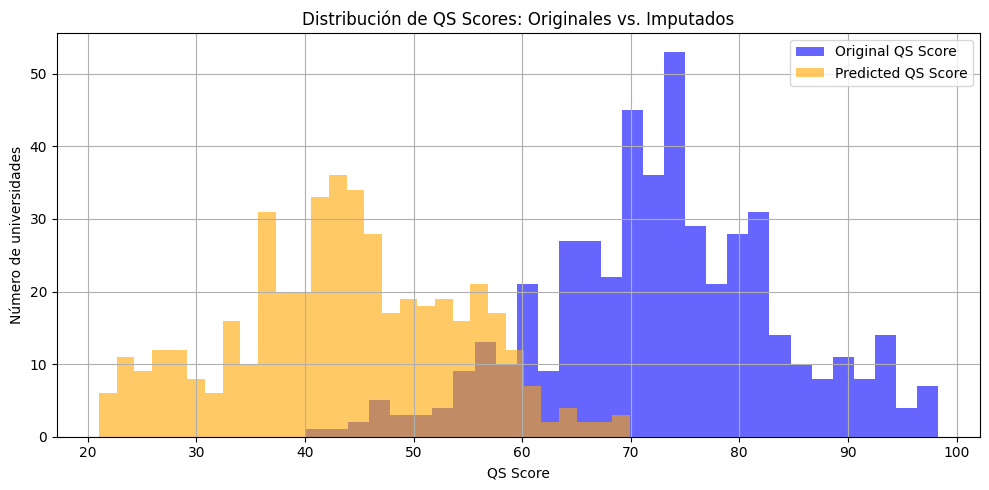

In [682]:
plt.figure(figsize=(10, 5))

# Reales
plt.hist(
    df_fl[df_fl["qs_valid"] == True]["qs_score"],
    bins=30,
    alpha=0.6,
    color="blue",
    label="Original QS Score"
)

# Imputados
plt.hist(
    df_fl[df_fl["qs_valid"] == False]["qs_score"],
    bins=30,
    alpha=0.6,
    color="orange",
    label="Predicted QS Score"
)

plt.title("Distribución de QS Scores: Originales vs. Imputados")
plt.xlabel("QS Score")
plt.ylabel("Número de universidades")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## Exportacion

In [683]:
df_fl = df_fl.drop(columns=["qs_valid", "bach"])
df_fl.to_pickle('ML_Aug.pkl')
df_qs.to_pickle('ML_QS.pkl')